In [1]:
# Copyright 2022 DeepMind Technologies Limited
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# %%
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
import pathlib
import PIL.Image
from tqdm.auto import tqdm
# set current directory: mujoco_mpc/python/mujoco_mpc
from mujoco_mpc import agent as agent_lib


In [2]:
# %matplotlib inline
base_path = pathlib.Path('/Users/eabe/Research/MyRepos/mujoco_mpc/')
# %%
# model
model_path = base_path / 'mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
# model_path = base_path / 'build/mjpc/tasks/cartpole/task.xml'
# pathlib.Path('/Users/eabe/Research/MyRepos/BiomechControl/models/fruitfly_v2/flybody/fruitfly/assets/fruitfly.xml')

model = mujoco.MjModel.from_xml_path(model_path.as_posix())

# data
data = mujoco.MjData(model)

# renderer
renderer = mujoco.Renderer(model)


In [3]:
from dm_control import mjcf

from flybody.utils import display_video, any_substr_in_str

In [8]:
site_size = 3 * (0.005,)
site_rgba = (0, 1, 1, 1)

# Load MJCF model from the fly XML file.
# mjcf_model = mjcf.from_path(model_path)
physics = mjcf.Physics.from_xml_path(model_path.as_posix())  # Load and compile.



In [ ]:
legs = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
joints = ['coxa', 'femur', 'tibia', 'tarsus']
xpos_geoms = ['coxa', 'femur', 'tibia', 'tarsus', 'claw']
joint_names = [f'{joint}_{leg}' for leg in legs for joint in joints]
xpos_names = [f'{joint}_{leg}' for leg in legs for joint in xpos_geoms]
fly_skel = np.array([(n,n+1) for n in range(29)])
fly_skel = np.stack((fly_skel[:4],fly_skel[5:9],fly_skel[10:14],fly_skel[15:19],fly_skel[20:24],fly_skel[25:30],))
# Set up colormap for plotting
import matplotlib as mpl
cmap = mpl.colormaps['Set1']
def map_discrete_cbar(cmap,N):
    cmap = plt.get_cmap(cmap,N+1)
    bounds = np.arange(-.5,N+1)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    return cmap, norm
cmap,norm = map_discrete_cbar('turbo',6)


In [119]:
subcom = physics.named.data.sensordata['thorax_subcom']
subcomvel = physics.named.data.sensordata['thorax_subcomvel']
subcom[2] =  1.0e-3
coxa_left = physics.named.data.xpos['coxa_T3_left']
coxa_right = physics.named.data.xpos['coxa_T3_right']
cap_point = subcom+subcomvel*.3
axis = coxa_right - coxa_left
ax_len = .5 * np.linalg.norm(coxa_right - coxa_left) - .05
center = (coxa_right + coxa_left)/2
vec = cap_point - center
t = vec.dot(axis) 
t = np.max([-ax_len,np.min([ax_len,t])])
vec = axis * t
pcp = vec + (coxa_right + coxa_left)/2
pcp[2] = 1.0e-3
thorax_height = physics.named.data.xpos['thorax'][2]
thorax_height / np.sqrt(thorax_height**2 + .1**2) #- .2
leg_pos = np.stack([physics.named.data.xpos[xpos_name] for xpos_name in xpos_names])

In [148]:
cap_point - center, cap_point,center, axis*t+center
(cap_point - pcp)[:2]

array([0.00372787, 0.00105964])

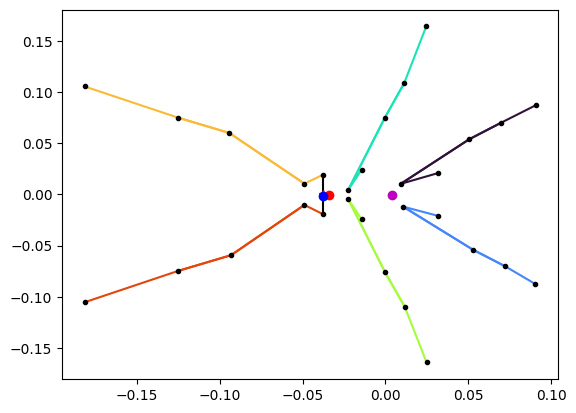

In [132]:
for n in range(fly_skel.shape[0]):
    plt.plot(leg_pos[fly_skel[n], 0], leg_pos[fly_skel[n], 1],c=cmap(n))
plt.plot([coxa_left[0],coxa_right[0]],[coxa_left[1],coxa_right[1]],'k')
plt.plot(cap_point[0],cap_point[1],'ro')
plt.plot(center[0],center[1],'r*')
plt.plot(pcp[0],pcp[1],'bo')
# plt.plot(vec[0],vec[1],'go')
# plt.plot(cap_point[0]-pcp[0],cap_point[1]-pcp[1],'go')
plt.plot(leg_pos[:,0],leg_pos[:,1],'k.')
plt.plot(cap_point[0] - center[0],cap_point[1] - center[1],'mo')

In [149]:
thorax_gyro = physics.named.data.sensordata['thorax_gyro']
thorax_gyro

array([0., 0., 0.])

In [145]:
np.mean(leg_pos[:, -1][4::5])

-0.12244897077987338

In [31]:
subcom, coxa_left, coxa_right

(array([-0.03397213, -0.00012308,  0.001     ]),
 array([-0.0144,  0.0241, -0.0425]),
 array([-0.0144, -0.0241, -0.0425]))

In [3]:

# %matplotlib inline
base_path = pathlib.Path('/Users/eabe/Research/MyRepos/mujoco_mpc/')
# %%
# model
model_path = base_path / 'mjpc/tasks/fruitfly/flytrackingqpos/task.xml'
# model_path = base_path / 'build/mjpc/tasks/cartpole/task.xml'
    # pathlib.Path('/Users/eabe/Research/MyRepos/BiomechControl/models/fruitfly_v2/flybody/fruitfly/assets/fruitfly.xml')

model = mujoco.MjModel.from_xml_path(model_path.as_posix())

# data
data = mujoco.MjData(model)

# renderer
renderer = mujoco.Renderer(model)

# %%
# agent
agent = agent_lib.Agent(task_id="Fruitfly Track", model=model)
# agent = agent_lib.Agent(task_id="Cartpole", model=model)

# weights
# agent.set_cost_weights({"Velocity": 0.15})
# print("cost_weights", agent.get_cost_weights())

# parameters
# agent.set_task_parameter("Height Goal", .1)
# print("Parameters:", agent.get_task_parameters())

# %%
# rollout horizon
T = 1500

# trajectories
qpos = np.zeros((model.nq, T))
qvel = np.zeros((model.nv, T))
ctrl = np.zeros((model.nu, T - 1))
time = np.zeros(T)

# costs
cost_total = np.zeros(T - 1)
cost_terms = np.zeros((len(agent.get_cost_term_values()), T - 1))

# rollout
mujoco.mj_resetData(model, data)

# cache initial state
qpos[:, 0] = data.qpos
qvel[:, 0] = data.qvel
time[0] = data.time

# frames
frames = []
FPS = 1.0 / model.opt.timestep


In [10]:

from dm_control.mujoco.wrapper.mjbindings import enums
import PIL.ImageDraw

scene_option = mujoco.wrapper.core.MjvOption()
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 1]
scene_option.flags[enums.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
renderer.update_scene(data)
pixels = renderer.render(camera_id=1, width=640, height=480,scene_option=scene_option)
PIL.Image.fromarray(pixels)

In [3]:

# simulate
for t in tqdm(range(T - 1)):
  if t % 100 == 0:
    print("t = ", t)

  # set planner state
  agent.set_state(
      time=data.time,
      qpos=data.qpos,
      qvel=data.qvel,
      act=data.act,
      mocap_pos=data.mocap_pos,
      mocap_quat=data.mocap_quat,
      userdata=data.userdata,
  )

  # run planner for num_steps
  num_steps = 10
  for _ in range(num_steps):
    agent.planner_step()

  # get costs
  cost_total[t] = agent.get_total_cost()
  for i, c in enumerate(agent.get_cost_term_values().items()):
    cost_terms[i, t] = c[1]

  # set ctrl from agent policy
  data.ctrl = agent.get_action()
  ctrl[:, t] = data.ctrl

  # step
  mujoco.mj_step(model, data)

  # cache
  qpos[:, t + 1] = data.qpos
  qvel[:, t + 1] = data.qvel
  time[t + 1] = data.time

  # render and save frames
  renderer.update_scene(data)
  pixels = renderer.render()
  frames.append(pixels)

# reset
agent.reset()


In [ ]:

# display video
# SLOWDOWN = 0.5
# media.show_video(frames, fps=SLOWDOWN * FPS)


In [ ]:

# %%
# plot position
fig = plt.figure()

plt.plot(time, qpos[0, :], label="q0", color="blue")
plt.plot(time, qpos[1, :], label="q1", color="orange")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Configuration")

# %%
# plot velocity
fig = plt.figure()

plt.plot(time, qvel[0, :], label="v0", color="blue")
plt.plot(time, qvel[1, :], label="v1", color="orange")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Velocity")

# %%
# plot control
fig = plt.figure()

plt.plot(time[:-1], ctrl[0, :], color="blue")

plt.xlabel("Time (s)")
plt.ylabel("Control")

# %%
# plot costs
fig = plt.figure()

for i, c in enumerate(agent.get_cost_term_values().items()):
  plt.plot(time[:-1], cost_terms[i, :], label=c[0])

plt.plot(time[:-1], cost_total, label="Total (weighted)", color="black")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Costs")


In [ ]:
plt.imshow(frames[1])